      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.6

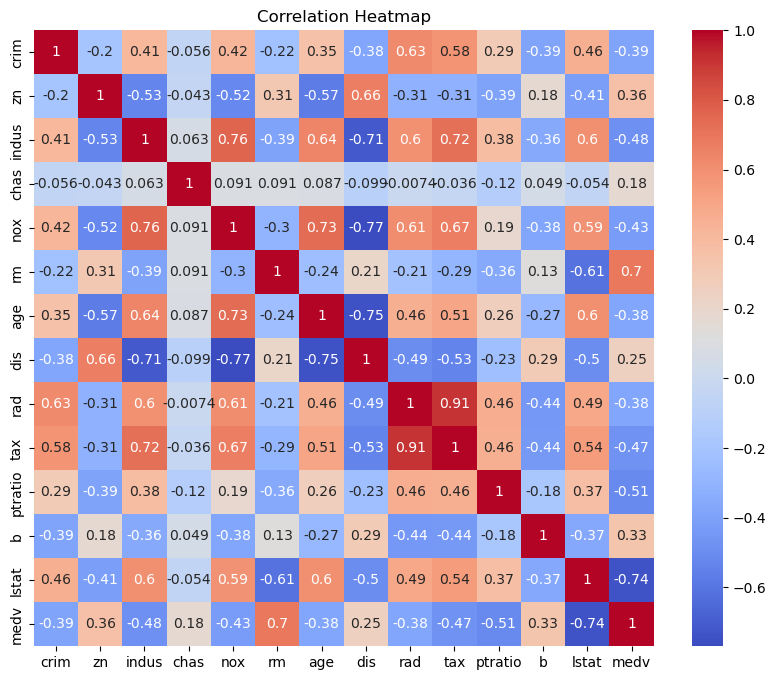

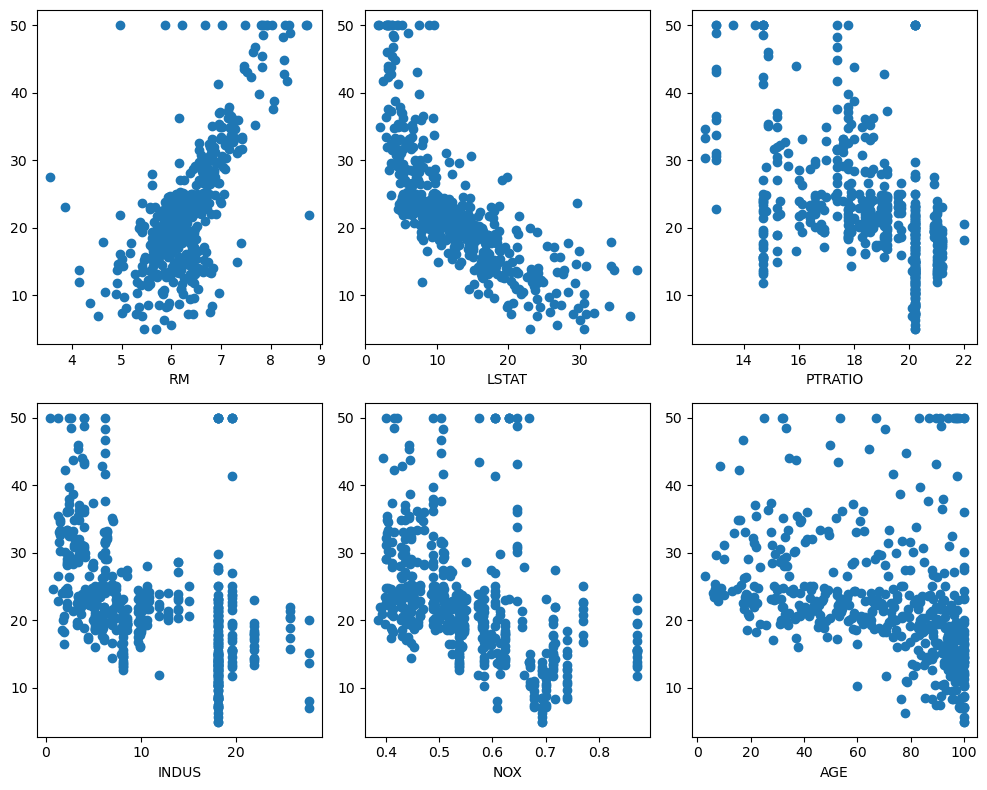

Mean Squared Error: 26.782523432699985
R2 Score: 0.6347860115964862
         Coefficient
rm          4.776817
lstat      -0.593496
ptratio    -0.948690
indus       0.065783
nox        -8.650123
age         0.032273


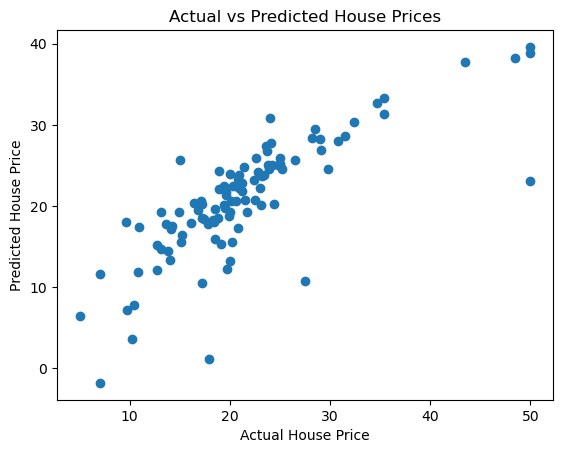

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print(df.head())
print(df.isnull().sum())
print(df.describe())

features = df[['rm','lstat','ptratio','indus','nox','age']]
target = df['medv']

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
plt.scatter(df['rm'], target)
plt.xlabel("RM")

plt.subplot(2,3,2)
plt.scatter(df['lstat'], target)
plt.xlabel("LSTAT")

plt.subplot(2,3,3)
plt.scatter(df['ptratio'], target)
plt.xlabel("PTRATIO")

plt.subplot(2,3,4)
plt.scatter(df['indus'], target)
plt.xlabel("INDUS")

plt.subplot(2,3,5)
plt.scatter(df['nox'], target)
plt.xlabel("NOX")

plt.subplot(2,3,6)
plt.scatter(df['age'], target)
plt.xlabel("AGE")

plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

coefficients = pd.DataFrame(model.coef_, features.columns, columns=['Coefficient'])
print(coefficients)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()